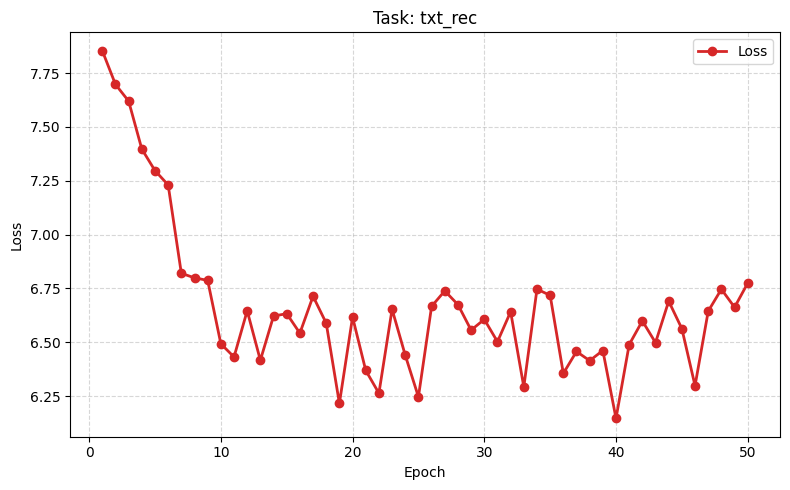

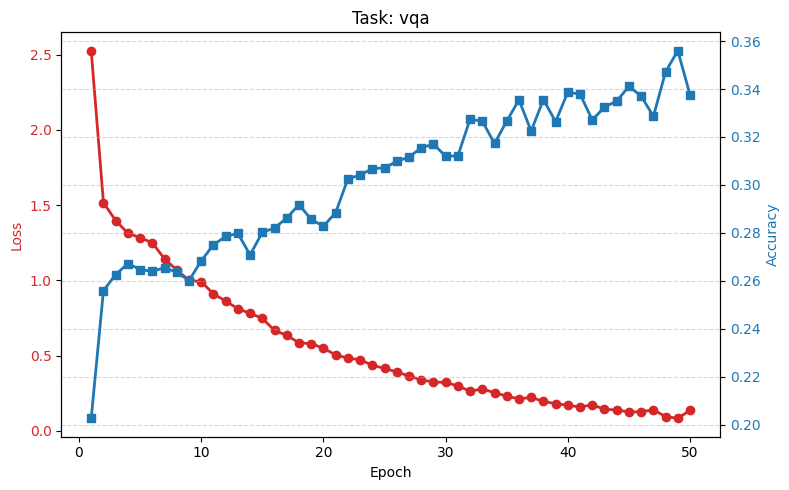

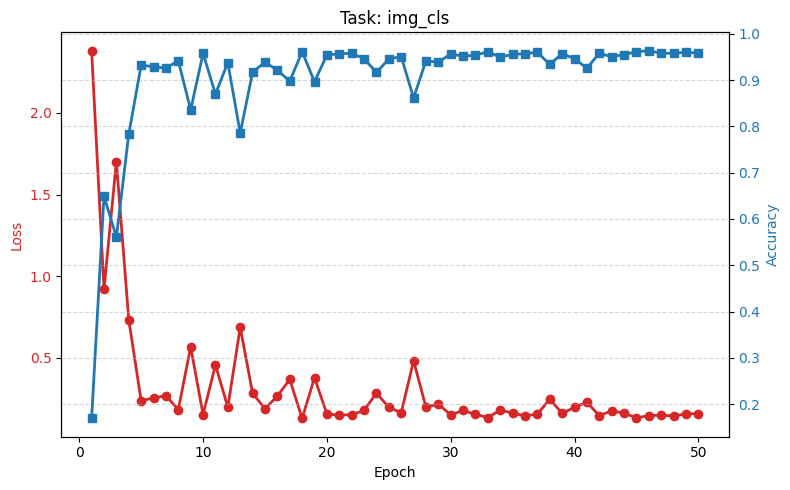

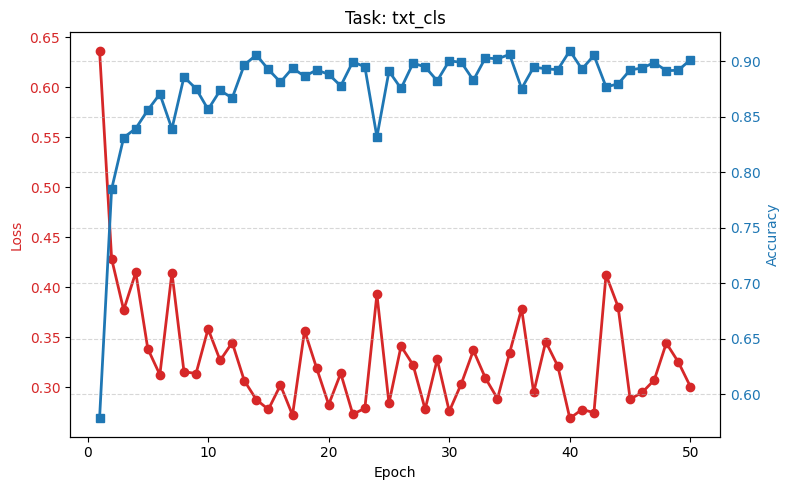

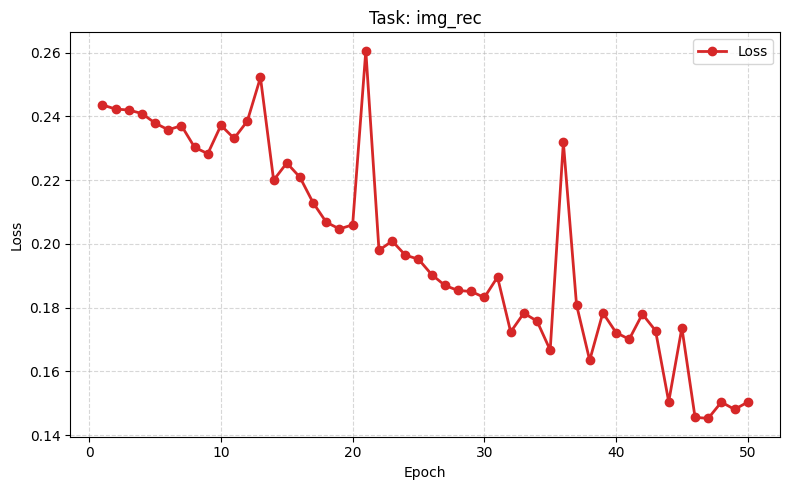

In [1]:
import re
import matplotlib.pyplot as plt

with open('./log/main_batch64_20260518_133357.log', 'r') as f:
    content = f.read()

# Clean up any potential artifacts like if present in the raw text
content = re.sub(r'\\s*', '', content)

metrics = {
    'txt_rec': {'loss': []},
    'vqa': {'loss': [], 'acc': []},
    'img_cls': {'loss': [], 'acc': []},
    'txt_cls': {'loss': [], 'acc': []},
    'img_rec': {'loss': []}
}

# Find all Evaluation blocks
eval_blocks = re.findall(r'Eval results:(.*?)(?===== Epoch|$)', content, re.DOTALL)

for block in eval_blocks:
    for task in metrics.keys():
        # Match from the task name to either the next task name, or end of block
        task_regex = rf'{task}:(.*?)(?=\n\s*\w+:|$)'
        task_chunk = re.search(task_regex, block, re.DOTALL)
        
        if task_chunk:
            chunk_str = task_chunk.group(1)
            loss_m = re.search(r'loss\s*=\s*([\d\.]+)', chunk_str)
            if loss_m:
                metrics[task]['loss'].append(float(loss_m.group(1)))
                
            if 'acc' in metrics[task]:
                acc_m = re.search(r'acc\s*=\s*([\d\.]+)', chunk_str)
                if acc_m:
                    metrics[task]['acc'].append(float(acc_m.group(1)))

# Generate a plot for each task
for task, data in metrics.items():
    epochs = range(1, len(data['loss']) + 1)
    
    # Skip if no data
    if len(epochs) == 0:
        continue
        
    if 'acc' in data and len(data['acc']) > 0:
        fig, ax1 = plt.subplots(figsize=(8, 5))

        color = 'tab:red'
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Loss', color=color)
        ax1.plot(epochs, data['loss'], color=color, marker='o', label='Loss', linewidth=2)
        ax1.tick_params(axis='y', labelcolor=color)

        ax2 = ax1.twinx()  
        color = 'tab:blue'
        ax2.set_ylabel('Accuracy', color=color)  
        ax2.plot(epochs, data['acc'], color=color, marker='s', label='Accuracy', linewidth=2)
        ax2.tick_params(axis='y', labelcolor=color)

        plt.title(f'Task: {task}')
        plt.grid(True, linestyle='--', alpha=0.5)
        fig.tight_layout()
        # plt.savefig(f'{task}_eval_results.png', dpi=150)
        plt.show()
        # plt.close(fig)
        
    else:
        plt.figure(figsize=(8, 5))
        plt.plot(epochs, data['loss'], color='tab:red', marker='o', label='Loss', linewidth=2)
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title(f'Task: {task}')
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.legend()
        plt.tight_layout()
        # plt.savefig(f'{task}_eval_results.png', dpi=150)
        plt.show()
        # plt.close()

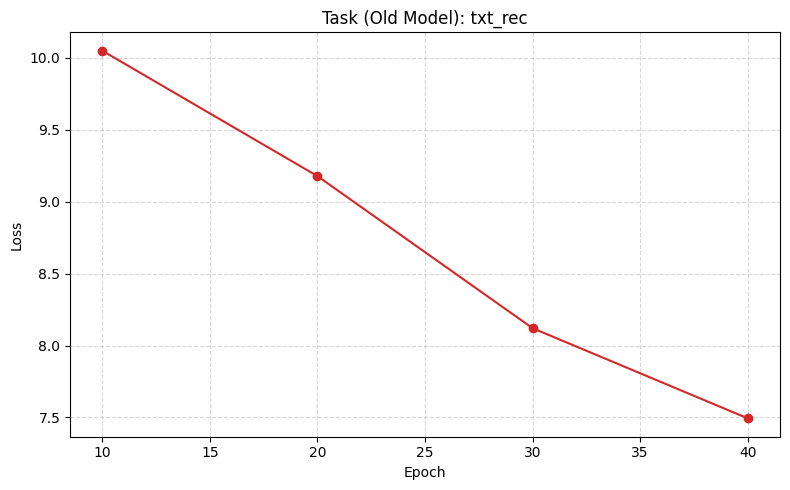

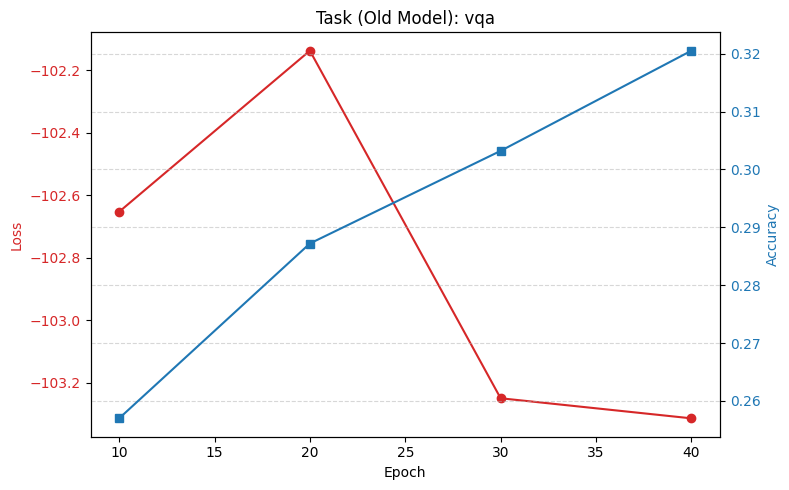

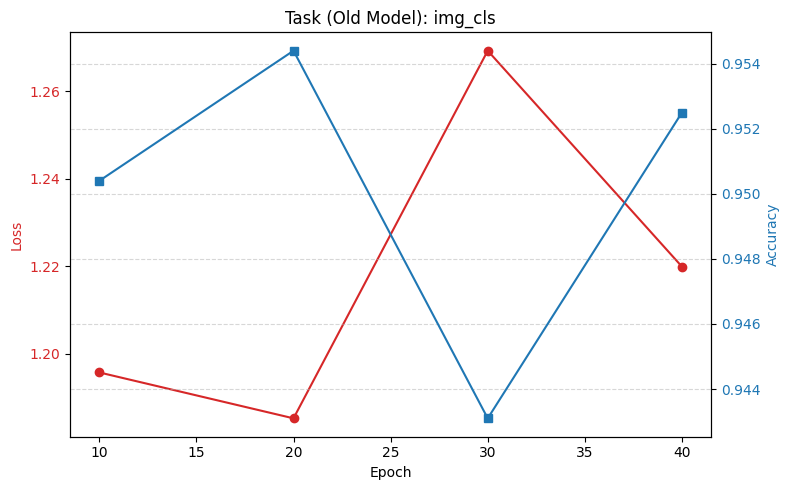

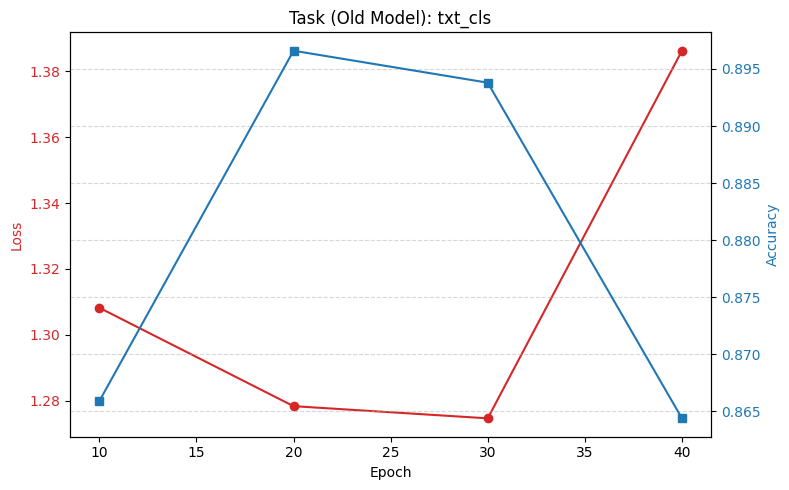

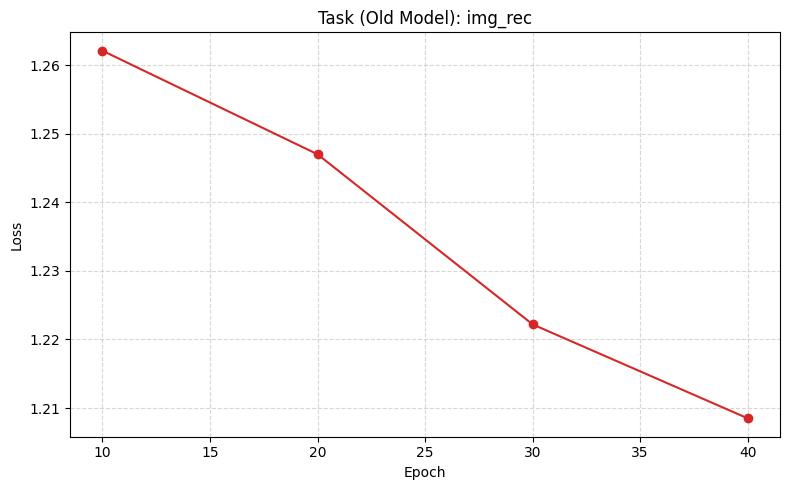

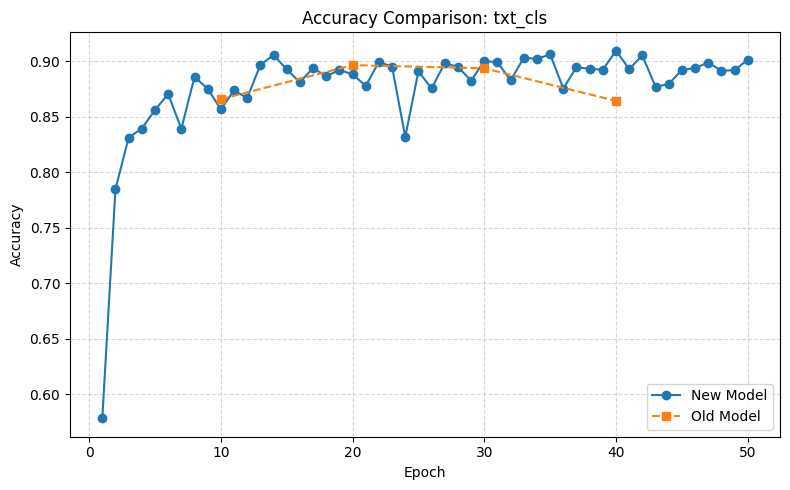

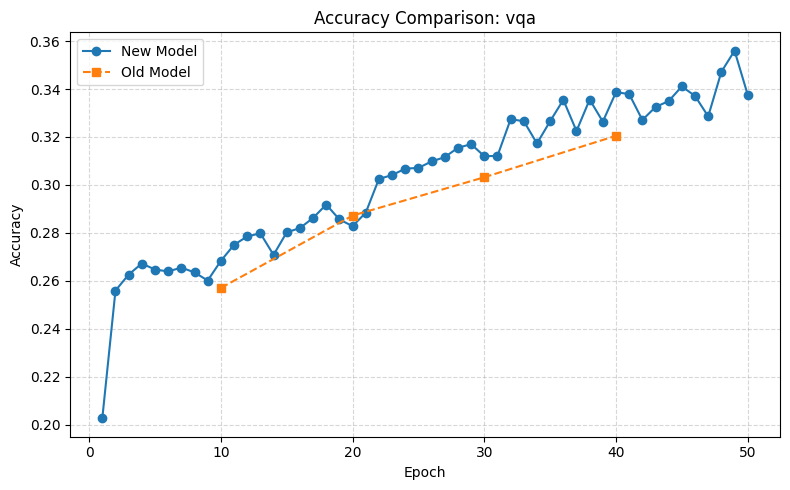

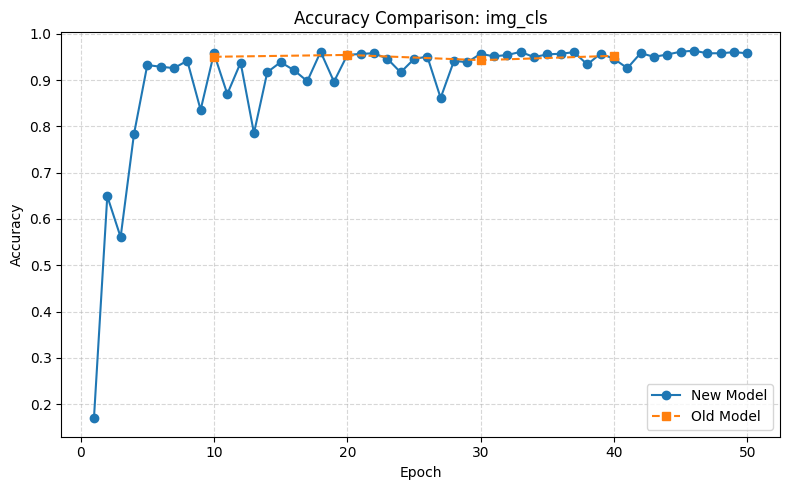

In [2]:
import re
import matplotlib.pyplot as plt

def parse_log(filename, eval_freq=1):
    with open(filename, 'r') as f:
        content = f.read()
    
    # Clean up source artifacts
    content = re.sub(r'\\s*', '', content)
    
    metrics = {
        'txt_rec': {'loss': []},
        'vqa': {'loss': [], 'acc': []},
        'img_cls': {'loss': [], 'acc': []},
        'txt_cls': {'loss': [], 'acc': []},
        'img_rec': {'loss': []}
    }
    
    eval_blocks = re.findall(r'Eval results:(.*?)(?===== Epoch|$)', content, re.DOTALL)
    epochs = []
    
    for i, block in enumerate(eval_blocks):
        epochs.append((i+1) * eval_freq)
        for task in metrics.keys():
            # Find loss
            loss_m = re.search(rf'{task}:.*?loss\s*=\s*([\-\d\.]+)', block, re.DOTALL)
            if loss_m:
                metrics[task]['loss'].append(float(loss_m.group(1)))
                
            # Find accuracy if applicable
            if 'acc' in metrics[task]:
                acc_m = re.search(rf'{task}:.*?acc\s*=\s*([\-\d\.]+)', block, re.DOTALL)
                if acc_m:
                    metrics[task]['acc'].append(float(acc_m.group(1)))
                    
    return epochs, metrics

epochs1, metrics1 = parse_log('./log/main_batch64_20260518_133357.log', eval_freq=1)
epochs2, metrics2 = parse_log('./log/main_newattnlog_20260401_064335.log', eval_freq=10)

# Generate plots for the new model
for task, data in metrics2.items():
    if len(epochs2) == 0 or len(data['loss']) == 0: continue
    
    if 'acc' in data and len(data['acc']) > 0:
        fig, ax1 = plt.subplots(figsize=(8, 5))
        color = 'tab:red'
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Loss', color=color)
        ax1.plot(epochs2, data['loss'], color=color, marker='o', label='Loss')
        ax1.tick_params(axis='y', labelcolor=color)
        
        ax2 = ax1.twinx()  
        color = 'tab:blue'
        ax2.set_ylabel('Accuracy', color=color)  
        ax2.plot(epochs2, data['acc'], color=color, marker='s', label='Accuracy')
        ax2.tick_params(axis='y', labelcolor=color)
        
        plt.title(f'Task (Old Model): {task}')
        plt.grid(True, linestyle='--', alpha=0.5)
        fig.tight_layout()
        # plt.savefig(f'{task}_new_model.png', dpi=150)
        plt.show()
    else:
        plt.figure(figsize=(8, 5))
        plt.plot(epochs2, data['loss'], color='tab:red', marker='o')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title(f'Task (Old Model): {task}')
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.tight_layout()
        # plt.savefig(f'{task}_new_model.png', dpi=150)
        plt.show()
        # plt.close()

# Generate comparison plots for txt_cls, vqa, img_cls
tasks_to_compare = ['txt_cls', 'vqa', 'img_cls']
for task in tasks_to_compare:
    plt.figure(figsize=(8, 5))
    plt.plot(epochs1, metrics1[task]['acc'], label='New Model', marker='o', linestyle='-', color='tab:blue')
    plt.plot(epochs2, metrics2[task]['acc'], label='Old Model', marker='s', linestyle='--', color='tab:orange')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title(f'Accuracy Comparison: {task}')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    # plt.savefig(f'{task}_comparison.png', dpi=150)
    plt.show()
    # plt.close()

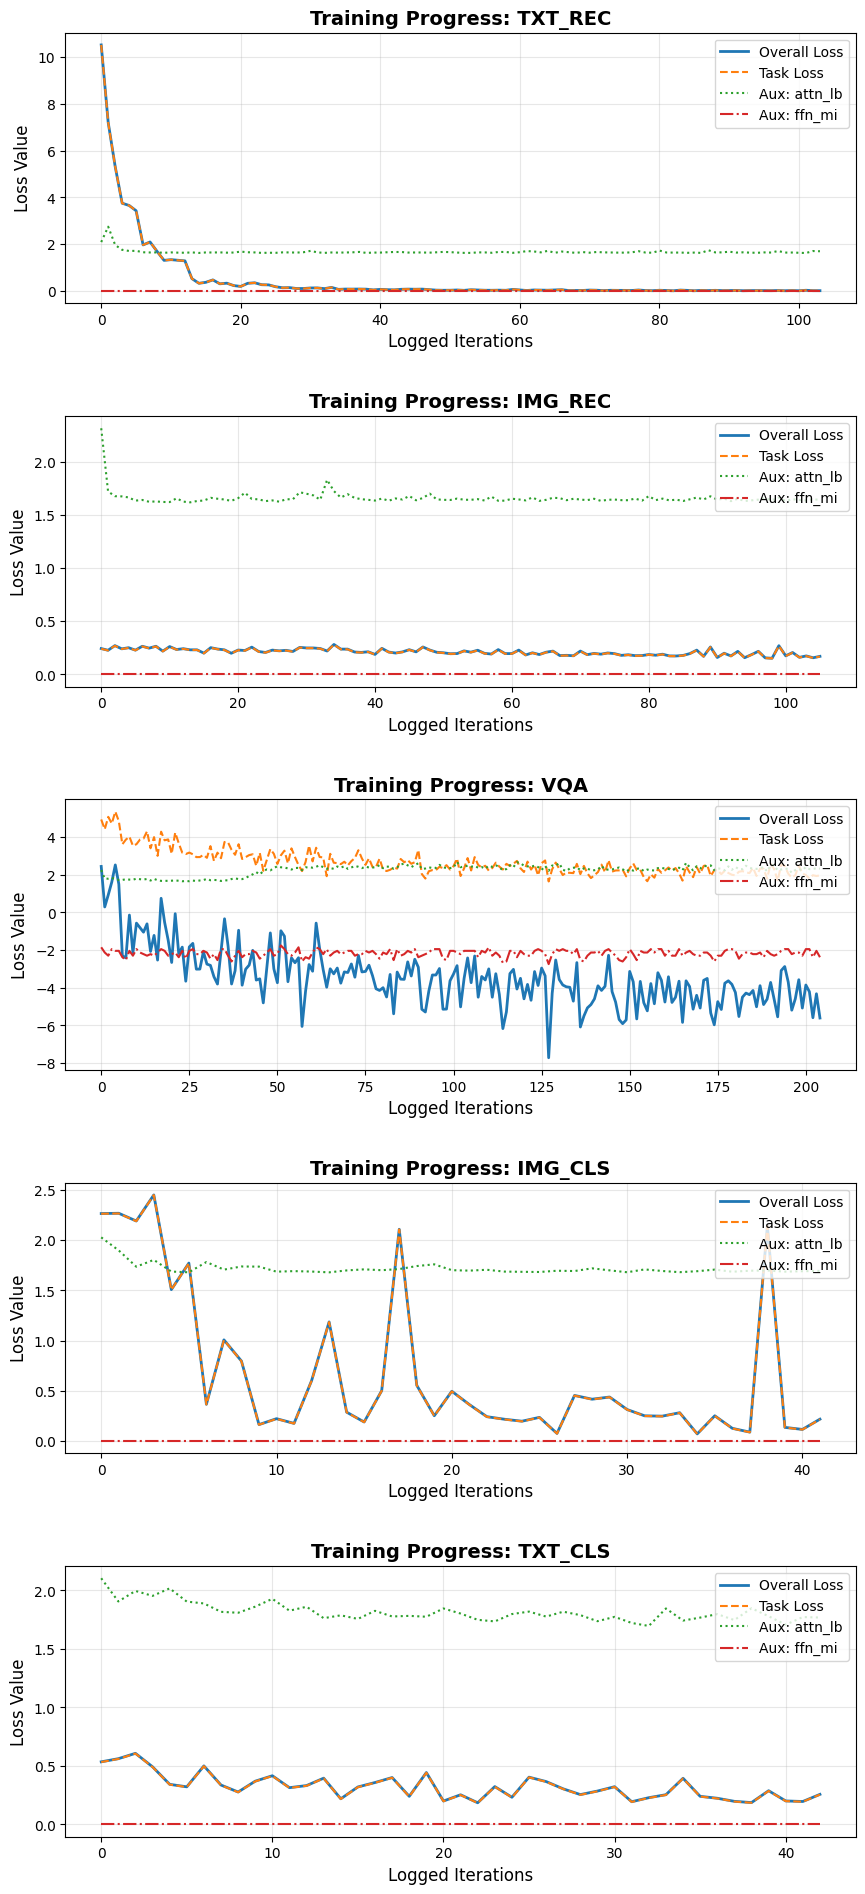

In [2]:
import re
import matplotlib.pyplot as plt

# Filepath to your provided training log
log_file_path = "./log/main_ver1.1_20260521_162119.log"

# The 5 tasks logged during training
tasks = ["txt_rec", "img_rec", "vqa", "img_cls", "txt_cls"]
metrics = ["loss", "loss_task", "attn_lb", "ffn_mi"]

# Initialize a dictionary of arrays for each metric under each task
data = {task: {metric: [] for metric in metrics} for task in tasks}

# Regex pattern to accurately capture the floating point and scientific notation values
pattern = re.compile(
    r"task=(?P<task>\w+)\s+"
    r"loss=(?P<loss>-?[\d\.]+)\s+"
    r"loss_task=(?P<loss_task>-?[\d\.]+)\s+"
    r"aux_loss=\{'attn_lb':\s*(?P<attn_lb>-?[\d\.e\-]+),\s*'ffn_mi':\s*(?P<ffn_mi>-?[\d\.e\-]+)\}"
)

# Extract and append the data into the arrays
with open(log_file_path, "r") as f:
    for line in f:
        match = pattern.search(line)
        if match:
            task = match.group("task")
            if task in data:
                data[task]["loss"].append(float(match.group("loss")))
                data[task]["loss_task"].append(float(match.group("loss_task")))
                data[task]["attn_lb"].append(float(match.group("attn_lb")))
                data[task]["ffn_mi"].append(float(match.group("ffn_mi")))

# Generate plots for each task
fig, axes = plt.subplots(len(tasks), 1, figsize=(10, 20))
fig.tight_layout(pad=6.0)

for i, task in enumerate(tasks):
    ax = axes[i]
    if data[task]["loss"]:  # Ensure we captured data for the task
        ax.plot(data[task]["loss"], label="Overall Loss", linewidth=2)
        ax.plot(data[task]["loss_task"], label="Task Loss", linestyle='--')
        ax.plot(data[task]["attn_lb"], label="Aux: attn_lb", linestyle=':')
        ax.plot(data[task]["ffn_mi"], label="Aux: ffn_mi", linestyle='-.')

        ax.set_title(f"Training Progress: {task.upper()}", fontsize=14, fontweight='bold')
        ax.set_xlabel("Logged Iterations", fontsize=12)
        ax.set_ylabel("Loss Value", fontsize=12)
        ax.legend(loc="upper right")
        ax.grid(True, alpha=0.3)

plt.show()

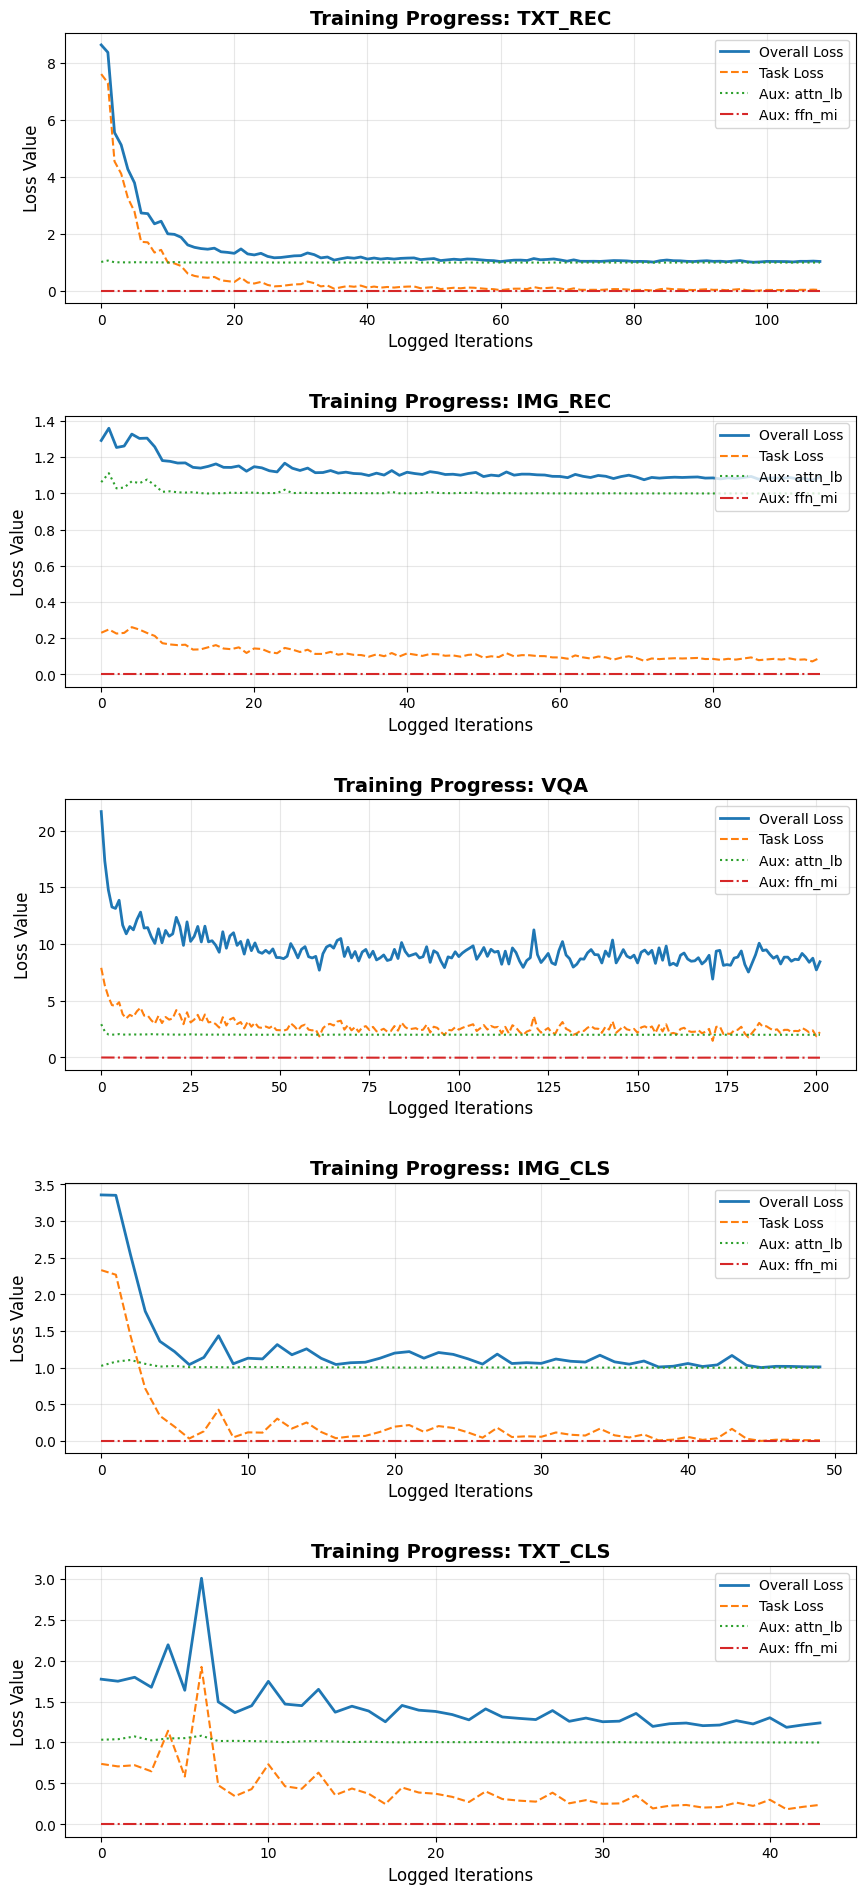

In [1]:
import re
import matplotlib.pyplot as plt

# Filepath to your provided training log
log_file_path = "./log/main_20260704_012756.log"

# The 5 tasks logged during training
tasks = ["txt_rec", "img_rec", "vqa", "img_cls", "txt_cls"]
metrics = ["loss", "loss_task", "attn_lb", "ffn_mi"]

# Initialize a dictionary of arrays for each metric under each task
data = {task: {metric: [] for metric in metrics} for task in tasks}

# Regex pattern to accurately capture the floating point and scientific notation values
pattern = re.compile(
    r"task=(?P<task>\w+)\s+"
    r"loss=(?P<loss>-?[\d\.]+)\s+"
    r"loss_task=(?P<loss_task>-?[\d\.]+)\s+"
    r"aux_loss=\{'attn_lb':\s*(?P<attn_lb>-?[\d\.e\-]+),\s*'ffn_mi':\s*(?P<ffn_mi>-?[\d\.e\-]+)\}"
)

# Extract and append the data into the arrays
with open(log_file_path, "r") as f:
    for line in f:
        match = pattern.search(line)
        if match:
            task = match.group("task")
            if task in data:
                data[task]["loss"].append(float(match.group("loss")))
                data[task]["loss_task"].append(float(match.group("loss_task")))
                data[task]["attn_lb"].append(float(match.group("attn_lb")))
                data[task]["ffn_mi"].append(float(match.group("ffn_mi")))

# Generate plots for each task
fig, axes = plt.subplots(len(tasks), 1, figsize=(10, 20))
fig.tight_layout(pad=6.0)

for i, task in enumerate(tasks):
    ax = axes[i]
    if data[task]["loss"]:  # Ensure we captured data for the task
        ax.plot(data[task]["loss"], label="Overall Loss", linewidth=2)
        ax.plot(data[task]["loss_task"], label="Task Loss", linestyle='--')
        ax.plot(data[task]["attn_lb"], label="Aux: attn_lb", linestyle=':')
        ax.plot(data[task]["ffn_mi"], label="Aux: ffn_mi", linestyle='-.')

        ax.set_title(f"Training Progress: {task.upper()}", fontsize=14, fontweight='bold')
        ax.set_xlabel("Logged Iterations", fontsize=12)
        ax.set_ylabel("Loss Value", fontsize=12)
        ax.legend(loc="upper right")
        ax.grid(True, alpha=0.3)

plt.show()

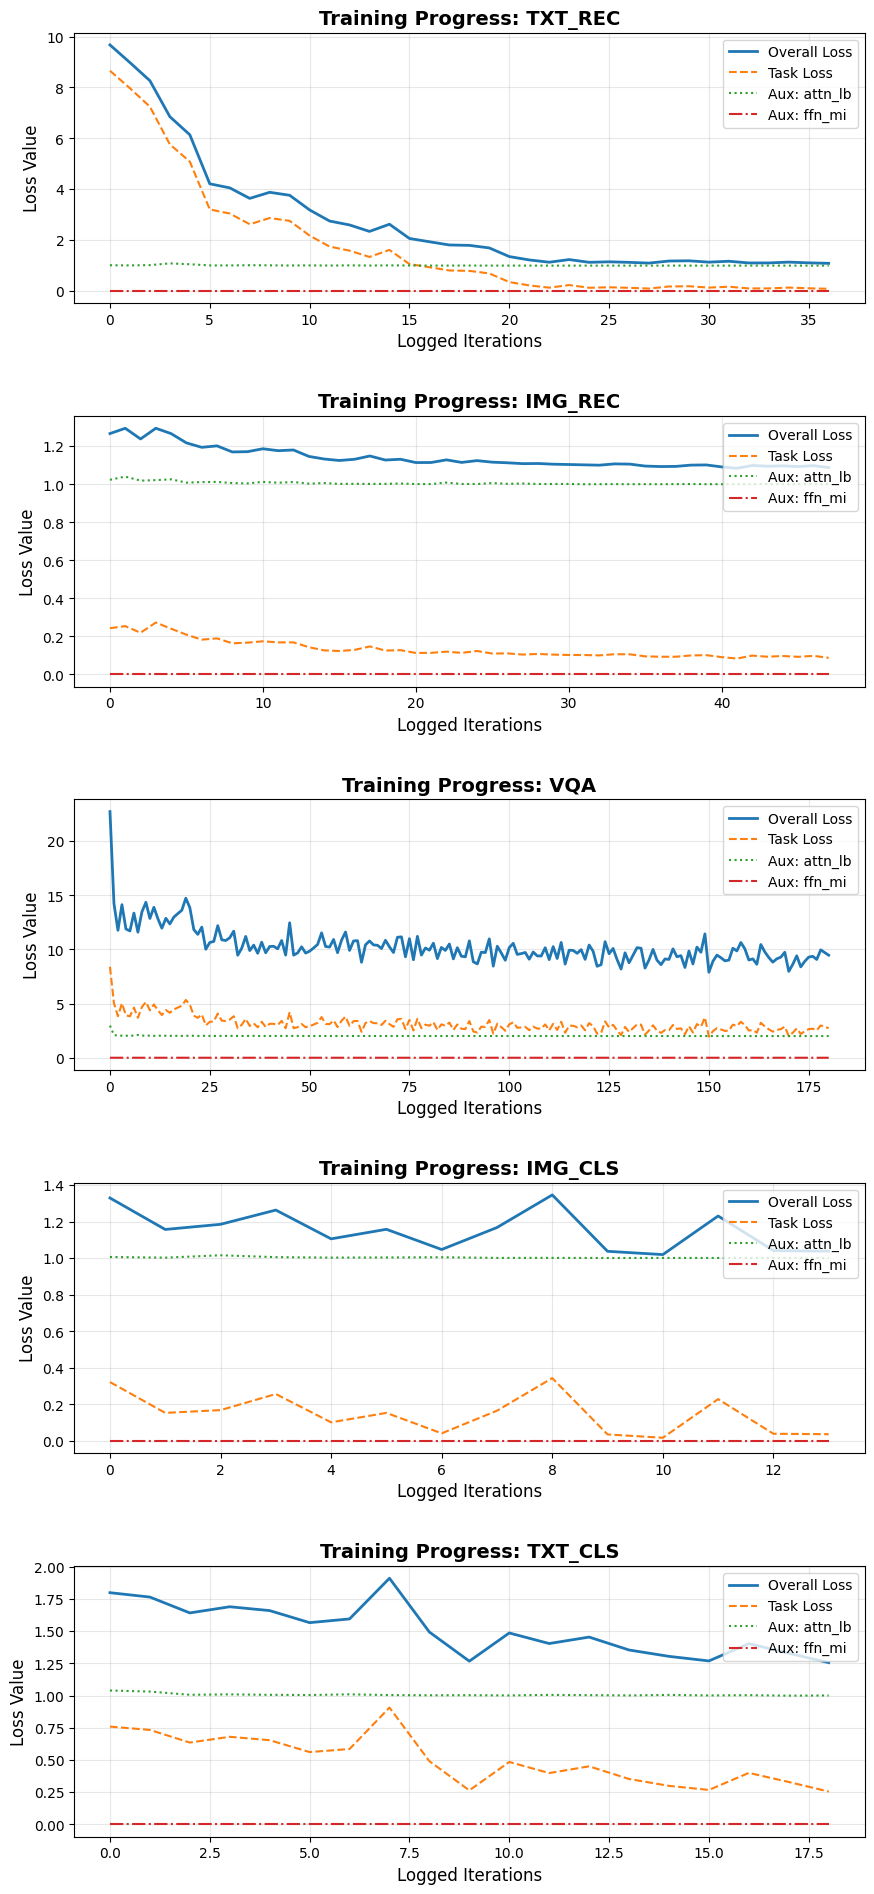

In [1]:
import re
import matplotlib.pyplot as plt

# Filepath to your provided training log
log_file_path = "./log/main_20260707_051527.log"

# The 5 tasks logged during training
tasks = ["txt_rec", "img_rec", "vqa", "img_cls", "txt_cls"]
metrics = ["loss", "loss_task", "attn_lb", "ffn_mi"]

# Initialize a dictionary of arrays for each metric under each task
data = {task: {metric: [] for metric in metrics} for task in tasks}

# Regex pattern to accurately capture the floating point and scientific notation values
pattern = re.compile(
    r"task=(?P<task>\w+)\s+"
    r"loss=(?P<loss>-?[\d\.]+)\s+"
    r"loss_task=(?P<loss_task>-?[\d\.]+)\s+"
    r"aux_loss=\{'attn_lb':\s*(?P<attn_lb>-?[\d\.e\-]+),\s*'ffn_mi':\s*(?P<ffn_mi>-?[\d\.e\-]+)\}"
)

# Extract and append the data into the arrays
with open(log_file_path, "r") as f:
    for line in f:
        match = pattern.search(line)
        if match:
            task = match.group("task")
            if task in data:
                data[task]["loss"].append(float(match.group("loss")))
                data[task]["loss_task"].append(float(match.group("loss_task")))
                data[task]["attn_lb"].append(float(match.group("attn_lb")))
                data[task]["ffn_mi"].append(float(match.group("ffn_mi")))

# Generate plots for each task
fig, axes = plt.subplots(len(tasks), 1, figsize=(10, 20))
fig.tight_layout(pad=6.0)

for i, task in enumerate(tasks):
    ax = axes[i]
    if data[task]["loss"]:  # Ensure we captured data for the task
        ax.plot(data[task]["loss"], label="Overall Loss", linewidth=2)
        ax.plot(data[task]["loss_task"], label="Task Loss", linestyle='--')
        ax.plot(data[task]["attn_lb"], label="Aux: attn_lb", linestyle=':')
        ax.plot(data[task]["ffn_mi"], label="Aux: ffn_mi", linestyle='-.')

        ax.set_title(f"Training Progress: {task.upper()}", fontsize=14, fontweight='bold')
        ax.set_xlabel("Logged Iterations", fontsize=12)
        ax.set_ylabel("Loss Value", fontsize=12)
        ax.legend(loc="upper right")
        ax.grid(True, alpha=0.3)

plt.show()

In [ ]:
        # num_imgs = 2

        # t_subset = (target[:num_imgs]*0.5 + 0.5)
        # r_subset = (recon[:num_imgs]*0.5 + 0.5)

        # # Calculate the absolute difference to see exactly where they differ
        # # Multiplying by a factor (e.g., 3) can help highlight subtle differences
        # diff = torch.abs(t_subset - r_subset) * 3  

        # # Stack them vertically: Top row = Target, Middle = Recon, Bottom = Difference
        # comparison = torch.cat([t_subset, r_subset, diff], dim=0)

        # # Save to disk as a single image
        # torchvision.utils.save_image(comparison, './log/visual_diff.png', nrow=num_imgs)
        # print("Saved visual_diff.png!")

        # raise NotImplementedError("Image reconstruction visualization saved. Check './log/visual_diff.png'.")

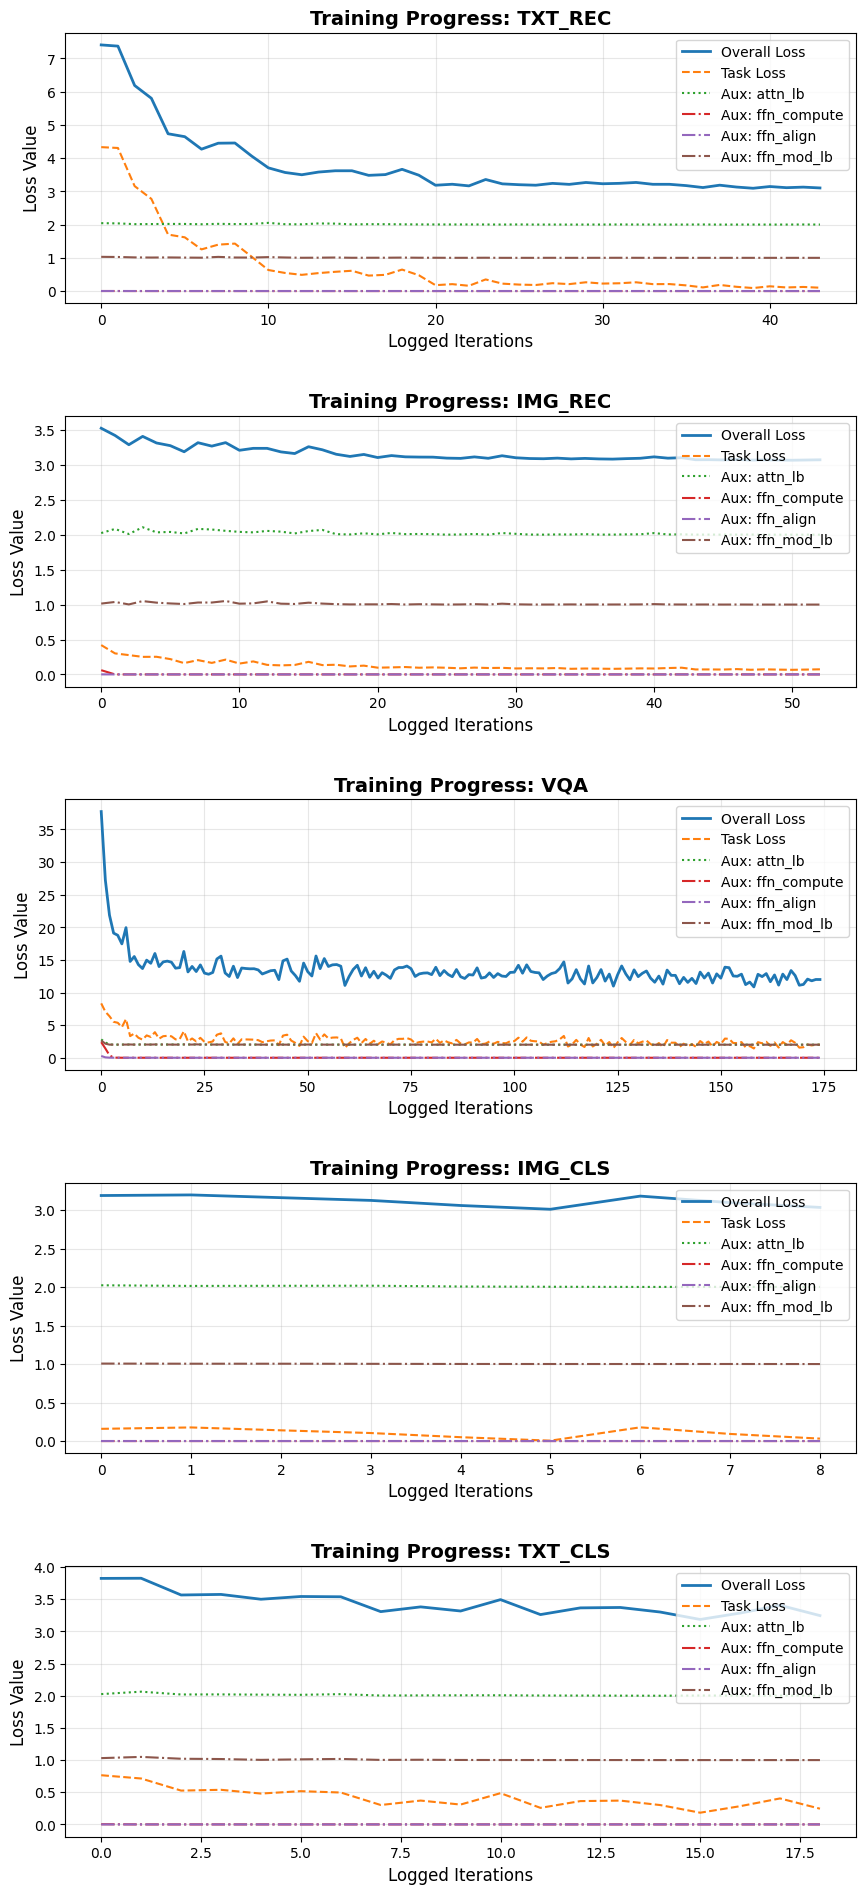

In [1]:
import re
import matplotlib.pyplot as plt

# Filepath to your provided training log
log_file_path = "./log/model_small_fixed_20260716_055924.log"

# The 5 tasks logged during training
tasks = ["txt_rec", "img_rec", "vqa", "img_cls", "txt_cls"]
# metrics = ["loss", "loss_task", "attn_lb", "ffn_mi"]
metrics = ["loss", "loss_task", "attn_lb", "ffn_compute", "ffn_align", "ffn_mod_lb"]


# Initialize a dictionary of arrays for each metric under each task
data = {task: {metric: [] for metric in metrics} for task in tasks}

# Regex pattern to accurately capture the floating point and scientific notation values
pattern = re.compile(
    r"task=(?P<task>\w+)\s+"
    r"loss=(?P<loss>-?[\d\.]+)\s+"
    r"loss_task=(?P<loss_task>-?[\d\.]+)\s+"
    r"aux_loss=\{'attn_lb':\s*(?P<attn_lb>-?[\d\.e\-]+),\s*'ffn_compute':\s*(?P<ffn_compute>-?[\d\.e\-]+),\s*'ffn_align':\s*(?P<ffn_align>-?[\d\.e\-]+),\s*'ffn_mod_lb':\s*(?P<ffn_mod_lb>-?[\d\.e\-]+)\}"
)

# Extract and append the data into the arrays
with open(log_file_path, "r") as f:
    for line in f:
        match = pattern.search(line)
        if match:
            task = match.group("task")
            if task in data:
                data[task]["loss"].append(float(match.group("loss")))
                data[task]["loss_task"].append(float(match.group("loss_task")))
                data[task]["attn_lb"].append(float(match.group("attn_lb")))
                data[task]["ffn_compute"].append(float(match.group("ffn_compute")))
                data[task]["ffn_align"].append(float(match.group("ffn_align")))
                data[task]["ffn_mod_lb"].append(float(match.group("ffn_mod_lb")))

# Generate plots for each task
fig, axes = plt.subplots(len(tasks), 1, figsize=(10, 20))
fig.tight_layout(pad=6.0)

for i, task in enumerate(tasks):
    ax = axes[i]
    if data[task]["loss"]:  # Ensure we captured data for the task
        ax.plot(data[task]["loss"], label="Overall Loss", linewidth=2)
        ax.plot(data[task]["loss_task"], label="Task Loss", linestyle='--')
        ax.plot(data[task]["attn_lb"], label="Aux: attn_lb", linestyle=':')
        ax.plot(data[task]["ffn_compute"], label="Aux: ffn_compute", linestyle='-.')
        ax.plot(data[task]["ffn_align"], label="Aux: ffn_align", linestyle='-.')
        ax.plot(data[task]["ffn_mod_lb"], label="Aux: ffn_mod_lb", linestyle='-.')

        ax.set_title(f"Training Progress: {task.upper()}", fontsize=14, fontweight='bold')
        ax.set_xlabel("Logged Iterations", fontsize=12)
        ax.set_ylabel("Loss Value", fontsize=12)
        ax.legend(loc="upper right")
        ax.grid(True, alpha=0.3)

plt.show()

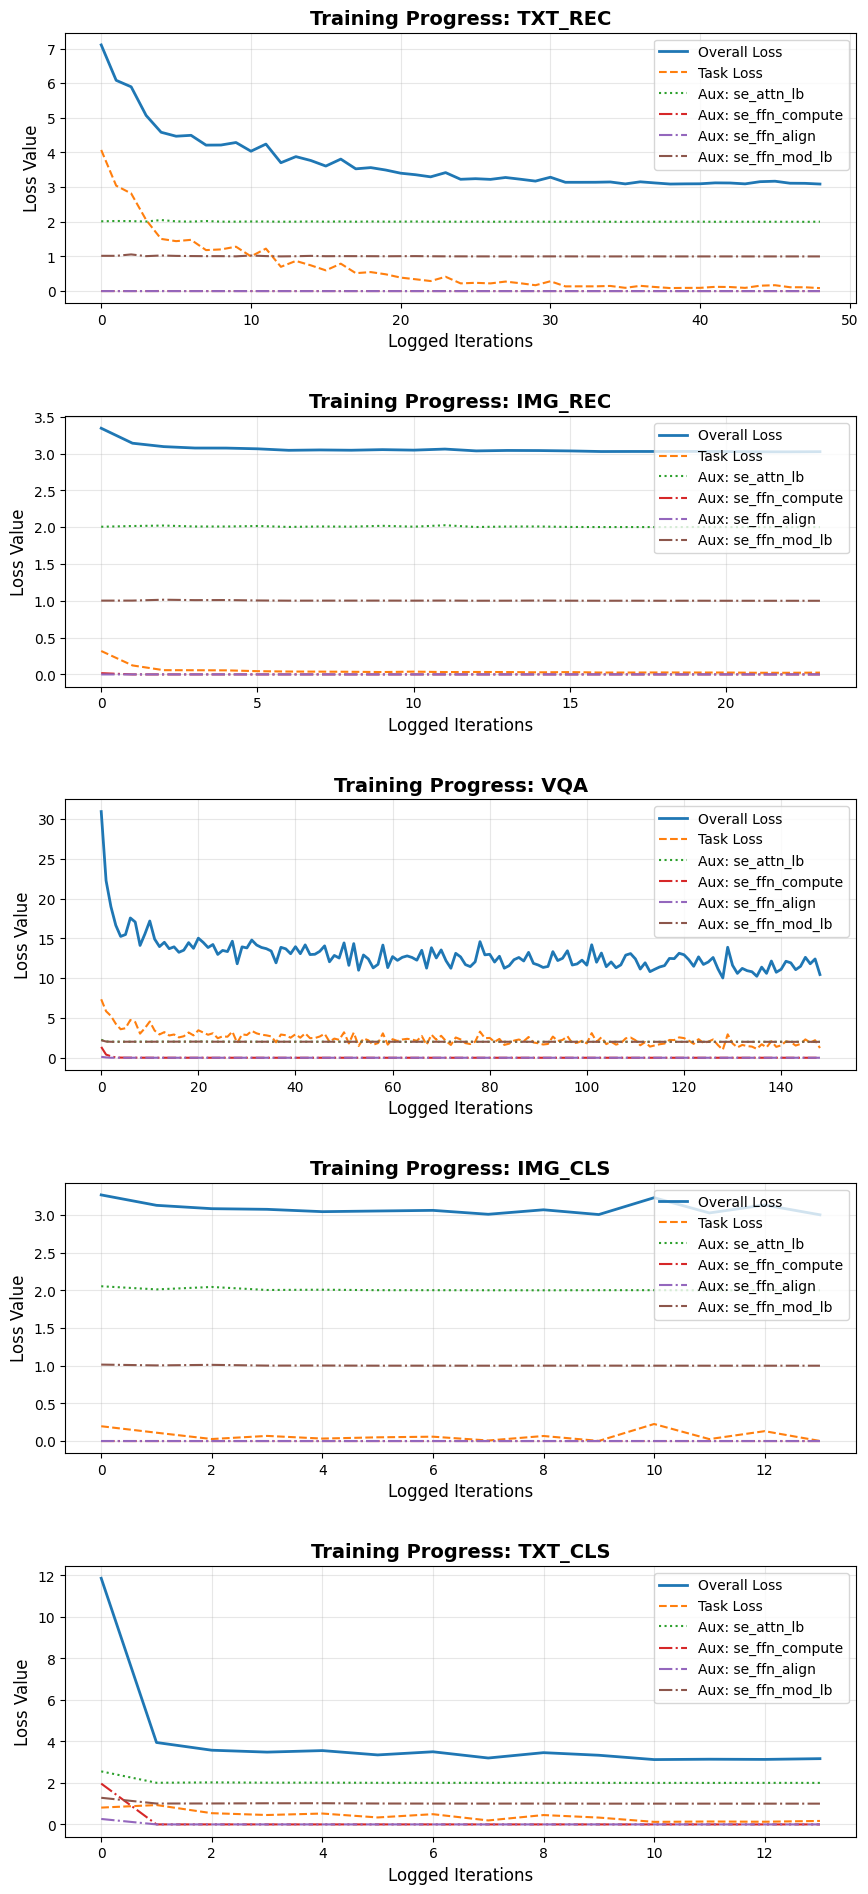

In [1]:
# THIS PLOT IS FOR MODEL WITH NO CHANNEL CODERS

import re
import matplotlib.pyplot as plt

# Filepath to your provided training log
log_file_path = "./log/semcom_huge_update_20260801_051202.log"

# The 5 tasks logged during training
tasks = ["txt_rec", "img_rec", "vqa", "img_cls", "txt_cls"]
# metrics = ["loss", "loss_task", "attn_lb", "ffn_mi"]
metrics = ["loss", "loss_task", "se_attn_lb", "se_ffn_compute", "se_ffn_align", "se_ffn_mod_lb"]


# Initialize a dictionary of arrays for each metric under each task
data = {task: {metric: [] for metric in metrics} for task in tasks}

# Regex pattern to accurately capture the floating point and scientific notation values
pattern = re.compile(
    r"task=(?P<task>\w+)\s+"
    r"loss=(?P<loss>-?[\d\.]+)\s+"
    r"loss_task=(?P<loss_task>-?[\d\.]+)\s+"
    r"aux_loss=\{'se_attn_lb':\s*(?P<se_attn_lb>-?[\d\.e\-]+),\s*'se_ffn_compute':\s*(?P<se_ffn_compute>-?[\d\.e\-]+),\s*'se_ffn_align':\s*(?P<se_ffn_align>-?[\d\.e\-]+),\s*'se_ffn_mod_lb':\s*(?P<se_ffn_mod_lb>-?[\d\.e\-]+)\}"
)

# Extract and append the data into the arrays
with open(log_file_path, "r") as f:
    for line in f:
        match = pattern.search(line)
        if match:
            task = match.group("task")
            if task in data:
                data[task]["loss"].append(float(match.group("loss")))
                data[task]["loss_task"].append(float(match.group("loss_task")))
                data[task]["se_attn_lb"].append(float(match.group("se_attn_lb")))
                data[task]["se_ffn_compute"].append(float(match.group("se_ffn_compute")))
                data[task]["se_ffn_align"].append(float(match.group("se_ffn_align")))
                data[task]["se_ffn_mod_lb"].append(float(match.group("se_ffn_mod_lb")))
                # data[task]["ce_router_lb"].append(float(match.group("ce_router_lb")))

# Generate plots for each task
fig, axes = plt.subplots(len(tasks), 1, figsize=(10, 20))
fig.tight_layout(pad=6.0)

for i, task in enumerate(tasks):
    ax = axes[i]
    if data[task]["loss"]:  # Ensure we captured data for the task
        ax.plot(data[task]["loss"], label="Overall Loss", linewidth=2)
        ax.plot(data[task]["loss_task"], label="Task Loss", linestyle='--')
        ax.plot(data[task]["se_attn_lb"], label="Aux: se_attn_lb", linestyle=':')
        ax.plot(data[task]["se_ffn_compute"], label="Aux: se_ffn_compute", linestyle='-.')
        ax.plot(data[task]["se_ffn_align"], label="Aux: se_ffn_align", linestyle='-.')
        ax.plot(data[task]["se_ffn_mod_lb"], label="Aux: se_ffn_mod_lb", linestyle='-.')
        # ax.plot(data[task]["ce_router_lb"], label="Aux: ce_router_lb", linestyle='-.')

        ax.set_title(f"Training Progress: {task.upper()}", fontsize=14, fontweight='bold')
        ax.set_xlabel("Logged Iterations", fontsize=12)
        ax.set_ylabel("Loss Value", fontsize=12)
        ax.legend(loc="upper right")
        ax.grid(True, alpha=0.3)

plt.show()

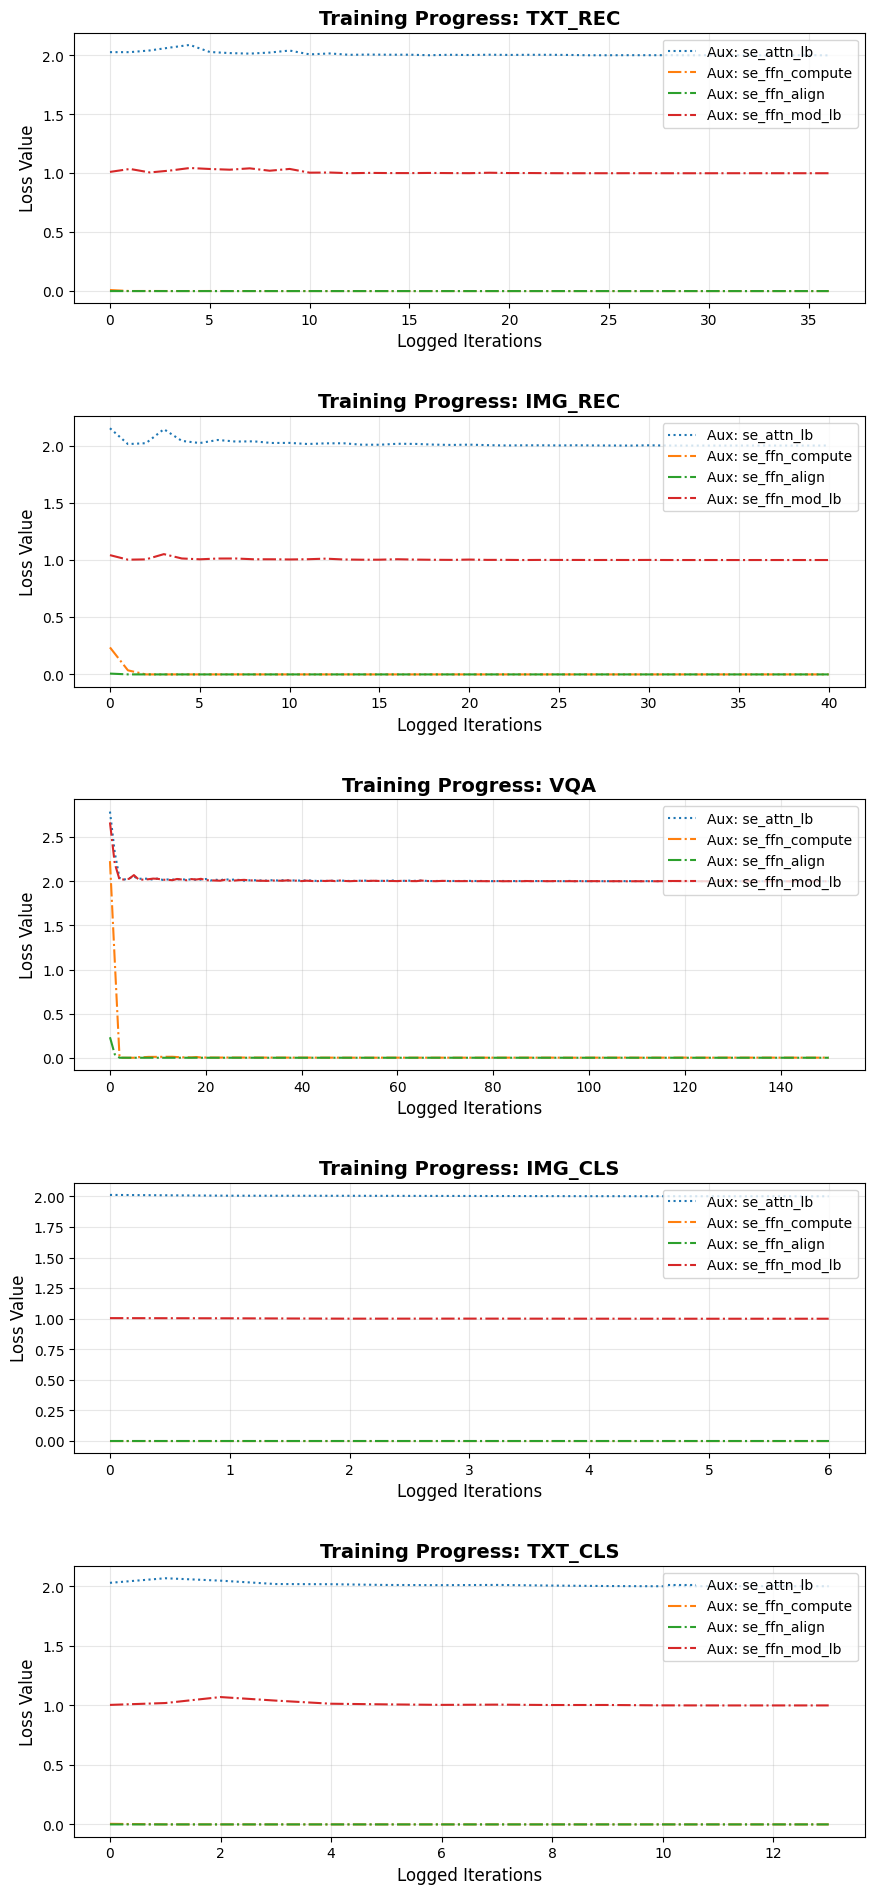

In [1]:
# THIS PLOT IS FOR MODEL WITH FULL CODERS

import re
import matplotlib.pyplot as plt

# Filepath to your provided training log
log_file_path = "./log/semcom_fullmodel_20dB_20260730_100724.log"

# The 5 tasks logged during training
tasks = ["txt_rec", "img_rec", "vqa", "img_cls", "txt_cls"]
# metrics = ["loss", "loss_task", "attn_lb", "ffn_mi"]
metrics = ["loss", "loss_task", "se_attn_lb", "se_ffn_compute", "se_ffn_align", "se_ffn_mod_lb", "ce_router_lb"]


# Initialize a dictionary of arrays for each metric under each task
data = {task: {metric: [] for metric in metrics} for task in tasks}

# Regex pattern to accurately capture the floating point and scientific notation values
pattern = re.compile(
    r"task=(?P<task>\w+)\s+"
    r"loss=(?P<loss>-?[\d\.]+)\s+"
    r"loss_task=(?P<loss_task>-?[\d\.]+)\s+"
    r"aux_loss=\{'se_attn_lb':\s*(?P<se_attn_lb>-?[\d\.e\-]+),\s*'se_ffn_compute':\s*(?P<se_ffn_compute>-?[\d\.e\-]+),\s*'se_ffn_align':\s*(?P<se_ffn_align>-?[\d\.e\-]+),\s*'se_ffn_mod_lb':\s*(?P<se_ffn_mod_lb>-?[\d\.e\-]+),\s*'ce_router_lb':\s*(?P<ce_router_lb>-?[\d\.e\-]+)\}"
)

# Extract and append the data into the arrays
with open(log_file_path, "r") as f:
    for line in f:
        match = pattern.search(line)
        if match:
            task = match.group("task")
            if task in data:
                data[task]["loss"].append(float(match.group("loss")))
                data[task]["loss_task"].append(float(match.group("loss_task")))
                data[task]["se_attn_lb"].append(float(match.group("se_attn_lb")))
                data[task]["se_ffn_compute"].append(float(match.group("se_ffn_compute")))
                data[task]["se_ffn_align"].append(float(match.group("se_ffn_align")))
                data[task]["se_ffn_mod_lb"].append(float(match.group("se_ffn_mod_lb")))
                data[task]["ce_router_lb"].append(float(match.group("ce_router_lb")))

# Generate plots for each task
fig, axes = plt.subplots(len(tasks), 1, figsize=(10, 20))
fig.tight_layout(pad=6.0)

for i, task in enumerate(tasks):
    ax = axes[i]
    if data[task]["loss"]:  # Ensure we captured data for the task
        # ax.plot(data[task]["loss"], label="Overall Loss", linewidth=2)
        # ax.plot(data[task]["loss_task"], label="Task Loss", linestyle='--')
        ax.plot(data[task]["se_attn_lb"], label="Aux: se_attn_lb", linestyle=':')
        ax.plot(data[task]["se_ffn_compute"], label="Aux: se_ffn_compute", linestyle='-.')
        ax.plot(data[task]["se_ffn_align"], label="Aux: se_ffn_align", linestyle='-.')
        ax.plot(data[task]["se_ffn_mod_lb"], label="Aux: se_ffn_mod_lb", linestyle='-.')
        # ax.plot(data[task]["ce_router_lb"], label="Aux: ce_router_lb", linestyle='-.')

        ax.set_title(f"Training Progress: {task.upper()}", fontsize=14, fontweight='bold')
        ax.set_xlabel("Logged Iterations", fontsize=12)
        ax.set_ylabel("Loss Value", fontsize=12)
        ax.legend(loc="upper right")
        ax.grid(True, alpha=0.3)

plt.show()